#DENOISING ENCODER

##0.REFERENCE AND CONTEXT

**Notebook title: Denoising Autoencoders for Robust Representation Learning with Fashion-MNIST**

**Introduction**

A denoising autoencoder is the natural next step after the basic autoencoder. In the previous notebook, the model learned to compress Fashion-MNIST images into a latent representation and reconstruct the original image. That experiment taught the basic encoder-decoder structure. The denoising autoencoder adds a more powerful idea: instead of reconstructing an image from a clean version of itself, the model receives a corrupted image and learns to reconstruct the clean original. This turns reconstruction into a problem of robust representation learning.

The intuition is simple but important. If a model receives a noisy image of a shoe, shirt, bag, or coat, and it must recover the clean version, it cannot merely copy pixels from input to output. It must learn something about the underlying structure of the image. It must learn that random noise is not part of the object. In this sense, the denoising autoencoder is forced to separate signal from corruption. This makes it a powerful teaching example because students can see the difference between memorizing input and learning structure.

Fashion-MNIST remains an excellent dataset for this tutorial because it gives us visual continuity. We already used Fashion-MNIST for convolutional neural networks and for basic autoencoders. Now we use it again to teach robustness. The images are small enough to run easily in Google Colab, but complex enough to show meaningful differences between clean, noisy, and reconstructed images.

The training setup is different from the basic autoencoder. In the basic autoencoder, the input and target were the same clean image. In the denoising autoencoder, the input is the noisy image, while the target is the clean image. The model therefore learns a mapping from corrupted observations to clean reconstructions. This is one of the most important ideas in modern representation learning: a model can learn useful internal structure by solving a carefully designed self-supervised task.

In this notebook, we build a convolutional denoising autoencoder. This is pedagogically useful because images have spatial structure. The encoder uses convolution and pooling to extract visual features from the noisy image. The decoder uses upsampling and convolution to reconstruct the clean image. The model is trained with reconstruction loss, comparing the reconstructed output against the original clean image.

The key visual result is a three-row grid: clean images, noisy inputs, and denoised reconstructions. Students can inspect whether the model has removed noise while preserving the core structure of the clothing item. We also compute reconstruction error and compare noisy-input error against denoised-output error. If the denoising autoencoder works, the reconstructed images should be closer to the clean originals than the noisy images were.

As in the rest of this project, the notebook follows the 10 cell plus 1 structure. The ten implementation cells handle environment setup, data loading, visualization, noise generation, dataset construction, model definition, training, evaluation, denoising visualization, and artifact export. The additional LLM cell uses GPT-5.2 to explain the results in structured JSON.

##1.LIBRARIES AND ENVIRONMENT

**Explanation for Cell 1**

This cell prepares the notebook environment. It imports the required libraries, fixes random seeds, creates folders for artifacts and saved models, and writes a run manifest. The manifest records the execution environment so that the experiment is easier to reproduce and audit.

In [1]:
import os
import json
import random
import platform
import datetime
import subprocess
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import mixed_precision

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

def get_gpu_report():
    try:
        result = subprocess.run(
            ["nvidia-smi"],
            capture_output=True,
            text=True,
            check=False
        )
        if result.returncode == 0:
            return result.stdout
        return "nvidia-smi is available but did not return a successful result."
    except Exception as error:
        return f"nvidia-smi is not available. Error: {error}"

physical_gpus = tf.config.list_physical_devices("GPU")
GPU_AVAILABLE = len(physical_gpus) > 0

if GPU_AVAILABLE:
    for gpu in physical_gpus:
        try:
            tf.config.experimental.set_memory_growth(gpu, True)
        except Exception as error:
            print("Could not set memory growth:", error)

    mixed_precision.set_global_policy("mixed_float16")
    COMPUTE_POLICY = "mixed_float16"
else:
    mixed_precision.set_global_policy("float32")
    COMPUTE_POLICY = "float32"

BATCH_SIZE_SMALL = 128 if GPU_AVAILABLE else 32
BATCH_SIZE_MEDIUM = 256 if GPU_AVAILABLE else 64
BATCH_SIZE_LARGE = 512 if GPU_AVAILABLE else 128

PROJECT_DIR = Path("/content/denoising_autoencoder_fashion_mnist_g4_project")
ARTIFACT_DIR = PROJECT_DIR / "artifacts"
MODEL_DIR = PROJECT_DIR / "model"

ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

RUN_ID = datetime.datetime.now(datetime.timezone.utc).strftime("run_%Y%m%d_%H%M%S_utc")

gpu_report = get_gpu_report()

environment_manifest = {
    "run_id": RUN_ID,
    "created_at_utc": datetime.datetime.now(datetime.timezone.utc).isoformat(),
    "python_version": platform.python_version(),
    "platform": platform.platform(),
    "tensorflow_version": tf.__version__,
    "numpy_version": np.__version__,
    "seed": SEED,
    "gpu_available": GPU_AVAILABLE,
    "tensorflow_physical_gpus": [str(gpu) for gpu in physical_gpus],
    "mixed_precision_policy": COMPUTE_POLICY,
    "batch_size_small": BATCH_SIZE_SMALL,
    "batch_size_medium": BATCH_SIZE_MEDIUM,
    "batch_size_large": BATCH_SIZE_LARGE,
    "gpu_report": gpu_report
}

manifest_path = ARTIFACT_DIR / "run_manifest.json"

with open(manifest_path, "w", encoding="utf-8") as f:
    json.dump(environment_manifest, f, indent=2)

print("Run ID:", RUN_ID)
print("TensorFlow version:", tf.__version__)
print("GPU available:", GPU_AVAILABLE)
print("Mixed precision policy:", COMPUTE_POLICY)
print("Batch size large:", BATCH_SIZE_LARGE)
print("Artifacts folder:", ARTIFACT_DIR)
print("\nGPU report")
print(gpu_report)

Run ID: run_20260604_194417_utc
TensorFlow version: 2.20.0
GPU available: True
Mixed precision policy: mixed_float16
Batch size large: 512
Artifacts folder: /content/denoising_autoencoder_fashion_mnist_g4_project/artifacts

GPU report
Thu Jun  4 19:44:17 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0

##2.LOADING THE MNIST FASHION DATASET

**Explanation for Cell 2**

This cell loads the Fashion-MNIST dataset. The model will not use labels during training because the denoising task is self-supervised. The labels are still kept for interpretation, allowing us to identify which clothing items are reconstructed well or poorly.

In [2]:
(X_train_raw, y_train_raw), (X_test_raw, y_test_raw) = keras.datasets.fashion_mnist.load_data()

class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

dataset_summary = {
    "training_images": int(X_train_raw.shape[0]),
    "test_images": int(X_test_raw.shape[0]),
    "image_height": int(X_train_raw.shape[1]),
    "image_width": int(X_train_raw.shape[2]),
    "channels": 1,
    "number_of_classes": int(len(class_names)),
    "class_names": class_names,
    "training_use_of_labels": "Labels are not used for denoising autoencoder training. They are used only for interpretation."
}

label_counts = {
    class_names[int(label)]: int(count)
    for label, count in zip(*np.unique(y_train_raw, return_counts=True))
}

print("Dataset summary")
print(json.dumps(dataset_summary, indent=2))

print("\nTraining label counts")
print(json.dumps(label_counts, indent=2))

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Dataset summary
{
  "training_images": 60000,
  "test_images": 10000,
  "image_height": 28,
  "image_width": 28,
  "channels": 1,
  "number_of_classes": 10,
  "class_names": [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
  ],
  "training_use_of_labels": "Labels are not used for denoising autoencoder training. They are used only for interpretation."
}

Training label counts
{
  "T-shirt/top": 6000,
  "Trouser": 6000,
  "Pullover": 6000,
  "Dress": 6000,
  "Coat": 6000,
  "Sandal": 6000,
  "Shirt": 6000,
  "Sneaker": 6000,
  "Bag": 6000,
  "Ankle boot": 6000
}


##3.VISUALIZATION

**Explanation for Cell 3**

This cell visualizes clean Fashion-MNIST images before adding noise. This gives students the baseline reference. Later, they will compare these clean originals against noisy inputs and denoised reconstructions.

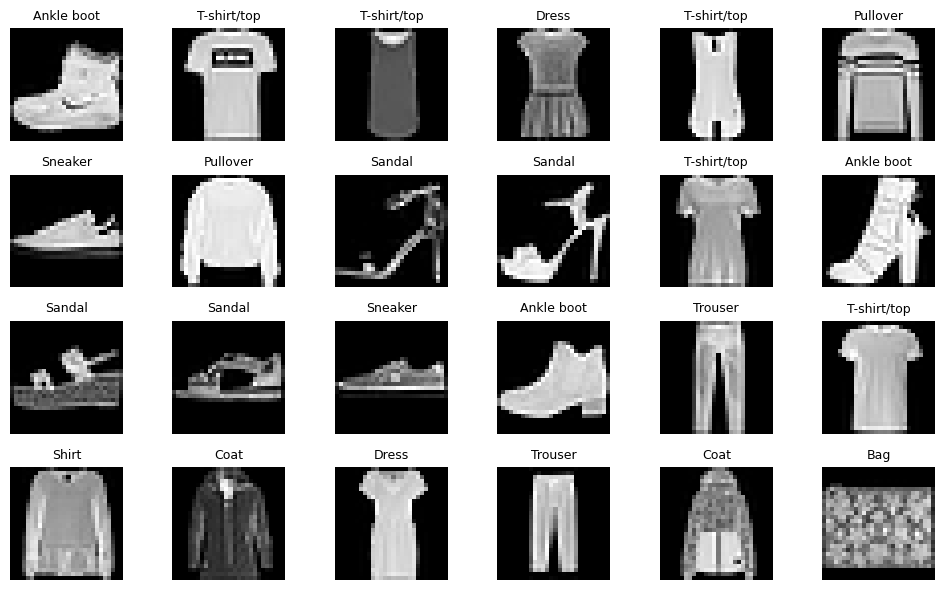

Saved clean image sample grid to: /content/denoising_autoencoder_fashion_mnist_g4_project/artifacts/clean_fashion_mnist_sample_grid.png


In [3]:
plt.figure(figsize=(10, 6))

for i in range(24):
    plt.subplot(4, 6, i + 1)
    plt.imshow(X_train_raw[i], cmap="gray")
    plt.title(class_names[int(y_train_raw[i])], fontsize=9)
    plt.axis("off")

plt.tight_layout()

clean_sample_grid_path = ARTIFACT_DIR / "clean_fashion_mnist_sample_grid.png"
plt.savefig(clean_sample_grid_path, dpi=150, bbox_inches="tight")
plt.show()

print("Saved clean image sample grid to:", clean_sample_grid_path)

##4.ADDING THE GAUSSIAN NOISE

**Explanation for Cell 4**

This cell scales the images and adds artificial Gaussian noise. The clean images become the targets, while the noisy images become the inputs. Clipping keeps pixel values inside the valid 0 to 1 range. This cell is the conceptual heart of the denoising setup: corrupted input, clean target.

In [4]:
NOISE_FACTOR = 0.35

X_train_clean = X_train_raw.astype("float32") / 255.0
X_test_clean = X_test_raw.astype("float32") / 255.0

X_train_clean = np.expand_dims(X_train_clean, axis=-1)
X_test_clean = np.expand_dims(X_test_clean, axis=-1)

rng = np.random.default_rng(SEED)

X_train_noisy = X_train_clean + NOISE_FACTOR * rng.normal(
    loc=0.0,
    scale=1.0,
    size=X_train_clean.shape
)

X_test_noisy = X_test_clean + NOISE_FACTOR * rng.normal(
    loc=0.0,
    scale=1.0,
    size=X_test_clean.shape
)

X_train_noisy = np.clip(X_train_noisy, 0.0, 1.0).astype("float32")
X_test_noisy = np.clip(X_test_noisy, 0.0, 1.0).astype("float32")

X_train = X_train_noisy[:50000]
X_val = X_train_noisy[50000:]

X_train_target = X_train_clean[:50000]
X_val_target = X_train_clean[50000:]

y_train = y_train_raw[:50000]
y_val = y_train_raw[50000:]

split_summary = {
    "training_samples": int(X_train.shape[0]),
    "validation_samples": int(X_val.shape[0]),
    "test_samples": int(X_test_noisy.shape[0]),
    "image_shape": list(X_train.shape[1:]),
    "noise_factor": float(NOISE_FACTOR),
    "input": "noisy image",
    "target": "clean image",
    "gpu_available": GPU_AVAILABLE,
    "mixed_precision_policy": COMPUTE_POLICY
}

print(json.dumps(split_summary, indent=2))
print("Noisy training tensor shape:", X_train.shape)
print("Clean target tensor shape:", X_train_target.shape)

{
  "training_samples": 50000,
  "validation_samples": 10000,
  "test_samples": 10000,
  "image_shape": [
    28,
    28,
    1
  ],
  "noise_factor": 0.35,
  "input": "noisy image",
  "target": "clean image",
  "gpu_available": true,
  "mixed_precision_policy": "mixed_float16"
}
Noisy training tensor shape: (50000, 28, 28, 1)
Clean target tensor shape: (50000, 28, 28, 1)


##5.VISUALIZATION OF CLEAN AND NOISED IMAGES

**Explanation for Cell 5**

This cell displays clean images and noisy images. This makes the denoising problem concrete. Students can see exactly what the model will receive as input and what it is expected to reconstruct.

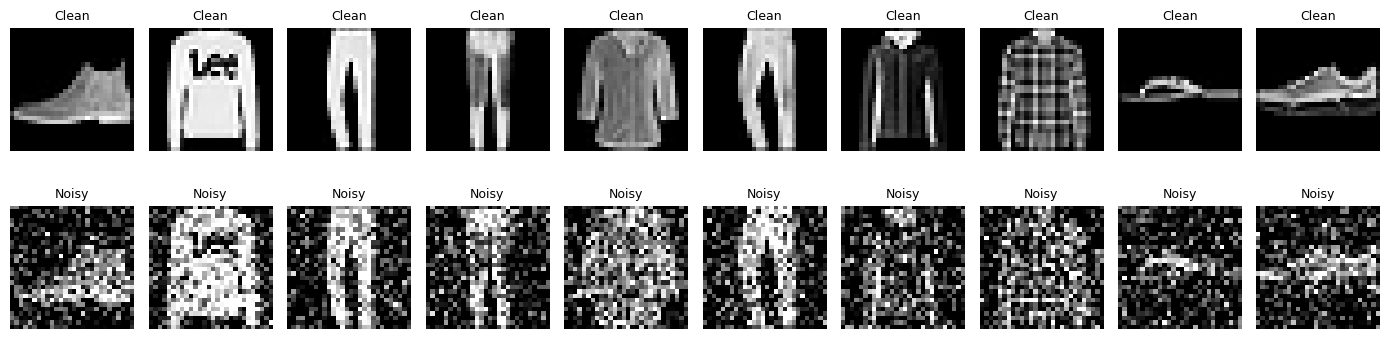

Saved clean versus noisy comparison to: /content/denoising_autoencoder_fashion_mnist_g4_project/artifacts/clean_vs_noisy_images.png


In [5]:
display_count = 10

plt.figure(figsize=(14, 4))

for i in range(display_count):
    plt.subplot(2, display_count, i + 1)
    plt.imshow(X_test_clean[i, :, :, 0], cmap="gray")
    plt.title("Clean", fontsize=9)
    plt.axis("off")

    plt.subplot(2, display_count, i + 1 + display_count)
    plt.imshow(X_test_noisy[i, :, :, 0], cmap="gray")
    plt.title("Noisy", fontsize=9)
    plt.axis("off")

plt.tight_layout()

noise_comparison_path = ARTIFACT_DIR / "clean_vs_noisy_images.png"
plt.savefig(noise_comparison_path, dpi=150, bbox_inches="tight")
plt.show()

print("Saved clean versus noisy comparison to:", noise_comparison_path)

##6.TENSORFLOW DATASET

**Explanation for Cell 6**

This cell creates GPU-aware TensorFlow datasets. The input is the noisy image, and the target is the clean image. The datasets use caching, batching, and prefetching to keep the GPU supplied with data. On a GPU runtime, the batch size is larger. On CPU, the notebook falls back to a smaller batch size.

In [6]:
BATCH_SIZE = BATCH_SIZE_LARGE

train_ds = (
    tf.data.Dataset
    .from_tensor_slices((X_train, X_train_target))
    .shuffle(buffer_size=len(X_train), seed=SEED)
    .cache()
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

val_ds = (
    tf.data.Dataset
    .from_tensor_slices((X_val, X_val_target))
    .cache()
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

test_ds = (
    tf.data.Dataset
    .from_tensor_slices((X_test_noisy, X_test_clean))
    .cache()
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

for batch_X, batch_y in train_ds.take(1):
    print("Noisy input batch shape:", batch_X.shape)
    print("Clean target batch shape:", batch_y.shape)
    print("Are input and target identical:", np.allclose(batch_X.numpy(), batch_y.numpy()))

print("Using batch size:", BATCH_SIZE)

Noisy input batch shape: (512, 28, 28, 1)
Clean target batch shape: (512, 28, 28, 1)
Are input and target identical: False
Using batch size: 512


##7.THE CONVOLUTIONAL DENOISING AUTOENCODER

**Explanation for Cell 7**

This cell builds the convolutional denoising autoencoder. The encoder uses convolution and pooling to extract compressed visual features from the noisy input. The decoder uses upsampling and convolution to reconstruct a clean image. The final output layer is explicitly set to float32, which is important when using mixed precision on GPU.

In [7]:
def build_convolutional_denoising_autoencoder(input_shape=(28, 28, 1)):
    inputs = keras.Input(shape=input_shape, name="noisy_image_input")

    x = layers.Conv2D(
        32,
        kernel_size=(3, 3),
        activation="relu",
        padding="same",
        name="encoder_conv_1"
    )(inputs)

    x = layers.MaxPooling2D(
        pool_size=(2, 2),
        padding="same",
        name="encoder_pool_1"
    )(x)

    x = layers.Conv2D(
        64,
        kernel_size=(3, 3),
        activation="relu",
        padding="same",
        name="encoder_conv_2"
    )(x)

    latent = layers.MaxPooling2D(
        pool_size=(2, 2),
        padding="same",
        name="compressed_latent_map"
    )(x)

    x = layers.Conv2D(
        64,
        kernel_size=(3, 3),
        activation="relu",
        padding="same",
        name="decoder_conv_1"
    )(latent)

    x = layers.UpSampling2D(
        size=(2, 2),
        name="decoder_upsample_1"
    )(x)

    x = layers.Conv2D(
        32,
        kernel_size=(3, 3),
        activation="relu",
        padding="same",
        name="decoder_conv_2"
    )(x)

    x = layers.UpSampling2D(
        size=(2, 2),
        name="decoder_upsample_2"
    )(x)

    outputs = layers.Conv2D(
        1,
        kernel_size=(3, 3),
        activation="sigmoid",
        padding="same",
        dtype="float32",
        name="denoised_image_output"
    )(x)

    model = keras.Model(
        inputs=inputs,
        outputs=outputs,
        name="fashion_mnist_convolutional_denoising_autoencoder_g4"
    )

    encoder = keras.Model(
        inputs=inputs,
        outputs=latent,
        name="fashion_mnist_denoising_encoder_g4"
    )

    return encoder, model

encoder, denoising_autoencoder = build_convolutional_denoising_autoencoder()

print("Encoder summary")
encoder.summary()

print("\nDenoising autoencoder summary")
denoising_autoencoder.summary()

print("\nGlobal mixed precision policy:", mixed_precision.global_policy())

Encoder summary


Model: "fashion_mnist_denoising_encoder_g4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ noisy_image_input (InputLayer)  │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_conv_1 (Conv2D)         │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_pool_1 (MaxPooling2D)   │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_conv_2 (Conv2D)         │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ compressed_latent_map           │ (None, 7, 7, 64)       │             0 │
│ (MaxPooling2D)                  │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,816 (73.50 KB)

 Trainable params: 18,816 (73.50 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ noisy_image_input (InputLayer)  │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_conv_1 (Conv2D)         │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_pool_1 (MaxPooling2D)   │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_conv_2 (Conv2D)         │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ compressed_latent_map           │ (None, 7, 7, 64)       │             0 │
│ (MaxPooling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_conv_1 (Conv2D)         │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_upsample_1              │ (None, 14, 14, 64)     │             0 │
│ (UpSampling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_conv_2 (Conv2D)         │ (None, 14, 14, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_upsample_2              │ (None, 28, 28, 32)     │             0 │
│ (UpSampling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ denoised_image_output (Conv2D)  │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,497 (291.00 KB)

 Trainable params: 74,497 (291.00 KB)

 Non-trainable params: 0 (0.00 B)


Global mixed precision policy: <DTypePolicy "mixed_float16">


###8.COMPILATION AND TRAINING

**Explanation for Cell 8**

This cell compiles and trains the denoising autoencoder. The loss function is mean squared error between the clean target image and the reconstructed output. The model learns to produce a clean image from a noisy input image. Early stopping restores the best validation model.

In [8]:
denoising_autoencoder.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="mse",
    metrics=["mae"]
)

early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history = denoising_autoencoder.fit(
    train_ds,
    validation_data=val_ds,
    epochs=40,
    callbacks=[early_stopping],
    verbose=1
)

history_dict = {
    key: [float(value) for value in values]
    for key, values in history.history.items()
}

history_path = ARTIFACT_DIR / "training_history.json"

with open(history_path, "w", encoding="utf-8") as f:
    json.dump(history_dict, f, indent=2)

print("Training history saved to:", history_path)

Epoch 1/40
98/98 ━━━━━━━━━━━━━━━━━━━━ 38s 184ms/step - loss: 0.0417 - mae: 0.1344 - val_loss: 0.0210 - val_mae: 0.0841
Epoch 2/40
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0190 - mae: 0.0788 - val_loss: 0.0178 - val_mae: 0.0751
Epoch 3/40
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0167 - mae: 0.0721 - val_loss: 0.0160 - val_mae: 0.0698
Epoch 4/40
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0155 - mae: 0.0687 - val_loss: 0.0151 - val_mae: 0.0672
Epoch 5/40
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0148 - mae: 0.0666 - val_loss: 0.0145 - val_mae: 0.0657
Epoch 6/40
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0142 - mae: 0.0649 - val_loss: 0.0140 - val_mae: 0.0642
Epoch 7/40
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0137 - mae: 0.0636 - val_loss: 0.0136 - val_mae: 0.0632
Epoch 8/40
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0133 - mae: 0.0624 - val_loss: 0.0132 - val_mae: 0.0621
Epoch 9/40
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0130 - ma

##9.EVALUATION

**Explanation for Cell 9**

This cell evaluates the denoising performance. It compares the error of the noisy input against the clean image with the error of the denoised reconstruction against the clean image. If the denoising autoencoder is working, the reconstructed images should have lower error than the noisy inputs.

Denoising summary
{
  "test_mse_loss": 0.010236128233373165,
  "test_mae": 0.05410914123058319,
  "mean_noisy_input_mse": 0.0685390830039978,
  "mean_denoised_output_mse": 0.010236128233373165,
  "median_noisy_input_mse": 0.06826207041740417,
  "median_denoised_output_mse": 0.009145337156951427,
  "mean_mse_improvement": 0.05830295383930206,
  "median_mse_improvement": 0.05857967585325241,
  "share_of_images_improved": 1.0,
  "batch_size": 512,
  "gpu_available": true,
  "mixed_precision_policy": "mixed_float16"
}


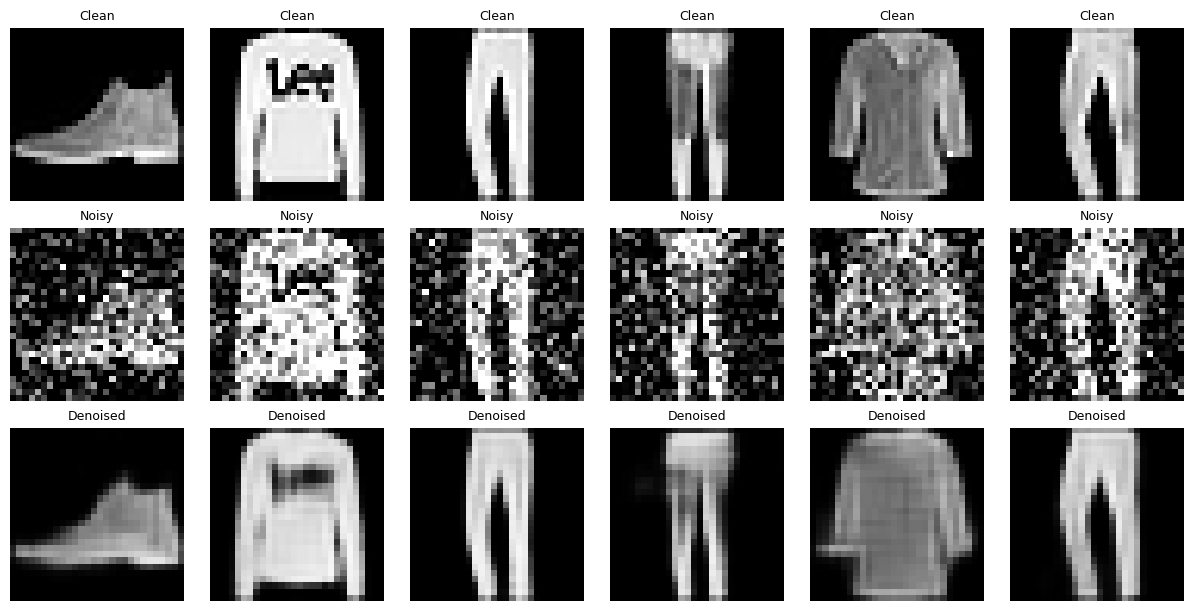

Saved denoising loss curve to: /content/denoising_autoencoder_fashion_mnist_g4_project/artifacts/denoising_loss_curve.png
Saved denoising summary to: /content/denoising_autoencoder_fashion_mnist_g4_project/artifacts/denoising_summary.json
Saved denoising comparison grid to: /content/denoising_autoencoder_fashion_mnist_g4_project/artifacts/clean_noisy_denoised_grid.png


In [13]:
from IPython.display import clear_output, display

epochs_ran = range(1, len(history.history["loss"]) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs_ran, history.history["loss"], label="Training denoising loss")
plt.plot(epochs_ran, history.history["val_loss"], label="Validation denoising loss")
plt.xlabel("Epoch")
plt.ylabel("Mean squared error")
plt.title("Training and Validation Denoising Loss")
plt.legend()
plt.grid(True)

loss_plot_path = ARTIFACT_DIR / "denoising_loss_curve.png"
plt.savefig(loss_plot_path, dpi=150, bbox_inches="tight")
plt.show()
plt.close()

test_loss, test_mae = denoising_autoencoder.evaluate(test_ds, verbose=0)

X_test_denoised = denoising_autoencoder.predict(
    X_test_noisy,
    batch_size=BATCH_SIZE,
    verbose=0
)

noisy_input_mse = np.mean(
    np.square(X_test_clean - X_test_noisy),
    axis=(1, 2, 3)
)

denoised_output_mse = np.mean(
    np.square(X_test_clean - X_test_denoised),
    axis=(1, 2, 3)
)

improvement_per_image = noisy_input_mse - denoised_output_mse

denoising_summary = {
    "test_mse_loss": float(test_loss),
    "test_mae": float(test_mae),
    "mean_noisy_input_mse": float(np.mean(noisy_input_mse)),
    "mean_denoised_output_mse": float(np.mean(denoised_output_mse)),
    "median_noisy_input_mse": float(np.median(noisy_input_mse)),
    "median_denoised_output_mse": float(np.median(denoised_output_mse)),
    "mean_mse_improvement": float(np.mean(improvement_per_image)),
    "median_mse_improvement": float(np.median(improvement_per_image)),
    "share_of_images_improved": float(np.mean(improvement_per_image > 0.0)),
    "batch_size": int(BATCH_SIZE),
    "gpu_available": bool(GPU_AVAILABLE),
    "mixed_precision_policy": COMPUTE_POLICY
}

denoising_summary_path = ARTIFACT_DIR / "denoising_summary.json"

with open(denoising_summary_path, "w", encoding="utf-8") as f:
    json.dump(denoising_summary, f, indent=2)

print("Denoising summary")
print(json.dumps(denoising_summary, indent=2))

display_count = 6

fig, axes = plt.subplots(
    nrows=3,
    ncols=display_count,
    figsize=(12, 6),
    constrained_layout=True
)

for i in range(display_count):
    axes[0, i].imshow(X_test_clean[i, :, :, 0], cmap="gray", vmin=0.0, vmax=1.0)
    axes[0, i].set_title("Clean", fontsize=9)
    axes[0, i].axis("off")

    axes[1, i].imshow(X_test_noisy[i, :, :, 0], cmap="gray", vmin=0.0, vmax=1.0)
    axes[1, i].set_title("Noisy", fontsize=9)
    axes[1, i].axis("off")

    axes[2, i].imshow(X_test_denoised[i, :, :, 0], cmap="gray", vmin=0.0, vmax=1.0)
    axes[2, i].set_title("Denoised", fontsize=9)
    axes[2, i].axis("off")

denoising_grid_path = ARTIFACT_DIR / "clean_noisy_denoised_grid.png"
fig.savefig(denoising_grid_path, dpi=150, bbox_inches="tight")

clear_output(wait=True)

print("Denoising summary")
print(json.dumps(denoising_summary, indent=2))

display(fig)
plt.close(fig)

print("Saved denoising loss curve to:", loss_plot_path)
print("Saved denoising summary to:", denoising_summary_path)
print("Saved denoising comparison grid to:", denoising_grid_path)

##10.SAVING THE TRAINED MODEL

**Explanation for Cell 10**

This cell saves the trained model and detailed denoising records. It also shows the best and worst denoising improvements. These examples help students understand when the model removes noise successfully and when it struggles to reconstruct the clean image.

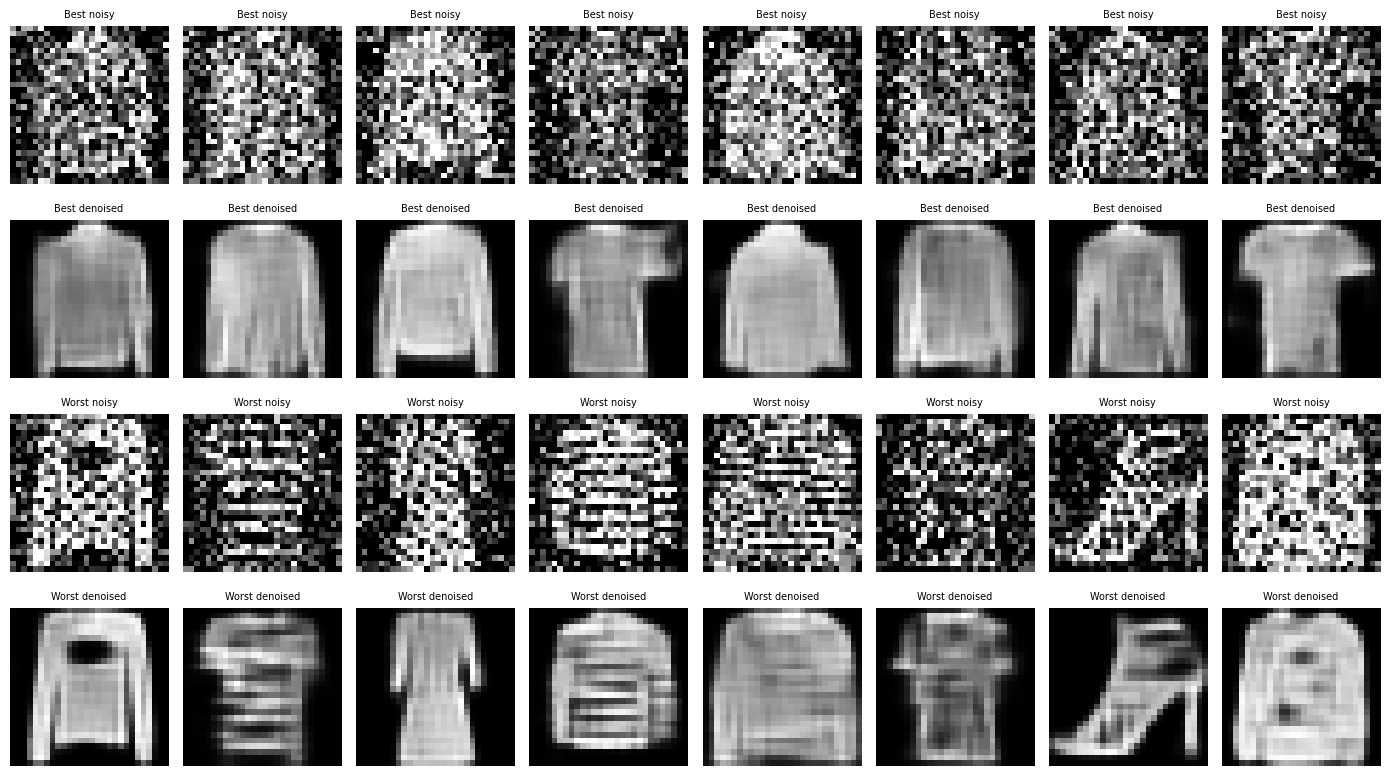

Saved denoising records to: /content/denoising_autoencoder_fashion_mnist_g4_project/artifacts/denoising_records.json
Saved best and worst denoising examples to: /content/denoising_autoencoder_fashion_mnist_g4_project/artifacts/best_and_worst_denoising_examples.png
Saved encoder to: /content/denoising_autoencoder_fashion_mnist_g4_project/model/fashion_mnist_denoising_encoder_g4.keras
Saved denoising autoencoder to: /content/denoising_autoencoder_fashion_mnist_g4_project/model/fashion_mnist_denoising_autoencoder_g4.keras
Saved artifact index to: /content/denoising_autoencoder_fashion_mnist_g4_project/artifacts/artifact_index.json


In [11]:
denoising_records = []

for i in range(len(X_test_clean)):
    denoising_records.append(
        {
            "test_index": int(i),
            "class_id": int(y_test_raw[i]),
            "class_name": class_names[int(y_test_raw[i])],
            "noisy_input_mse": float(noisy_input_mse[i]),
            "denoised_output_mse": float(denoised_output_mse[i]),
            "mse_improvement": float(improvement_per_image[i]),
            "improved": bool(improvement_per_image[i] > 0.0)
        }
    )

denoising_records_path = ARTIFACT_DIR / "denoising_records.json"

with open(denoising_records_path, "w", encoding="utf-8") as f:
    json.dump(denoising_records, f, indent=2)

sorted_by_improvement = np.argsort(improvement_per_image)

worst_improvement_indices = sorted_by_improvement[:8]
best_improvement_indices = sorted_by_improvement[-8:][::-1]

plt.figure(figsize=(14, 8))

for position, image_index in enumerate(best_improvement_indices):
    plt.subplot(4, 8, position + 1)
    plt.imshow(X_test_noisy[image_index, :, :, 0], cmap="gray")
    plt.title("Best noisy", fontsize=7)
    plt.axis("off")

    plt.subplot(4, 8, position + 9)
    plt.imshow(X_test_denoised[image_index, :, :, 0], cmap="gray")
    plt.title("Best denoised", fontsize=7)
    plt.axis("off")

for position, image_index in enumerate(worst_improvement_indices):
    plt.subplot(4, 8, position + 17)
    plt.imshow(X_test_noisy[image_index, :, :, 0], cmap="gray")
    plt.title("Worst noisy", fontsize=7)
    plt.axis("off")

    plt.subplot(4, 8, position + 25)
    plt.imshow(X_test_denoised[image_index, :, :, 0], cmap="gray")
    plt.title("Worst denoised", fontsize=7)
    plt.axis("off")

plt.tight_layout()

best_worst_denoising_path = ARTIFACT_DIR / "best_and_worst_denoising_examples.png"
plt.savefig(best_worst_denoising_path, dpi=150, bbox_inches="tight")
plt.show()

encoder_path = MODEL_DIR / "fashion_mnist_denoising_encoder_g4.keras"
denoising_model_path = MODEL_DIR / "fashion_mnist_denoising_autoencoder_g4.keras"

encoder.save(encoder_path)
denoising_autoencoder.save(denoising_model_path)

final_artifact_index = {
    "run_id": RUN_ID,
    "manifest_path": str(manifest_path),
    "history_path": str(history_path),
    "denoising_summary_path": str(denoising_summary_path),
    "denoising_records_path": str(denoising_records_path),
    "loss_plot_path": str(loss_plot_path),
    "clean_noisy_denoised_grid_path": str(denoising_grid_path),
    "best_worst_denoising_path": str(best_worst_denoising_path),
    "encoder_path": str(encoder_path),
    "denoising_model_path": str(denoising_model_path)
}

artifact_index_path = ARTIFACT_DIR / "artifact_index.json"

with open(artifact_index_path, "w", encoding="utf-8") as f:
    json.dump(final_artifact_index, f, indent=2)

print("Saved denoising records to:", denoising_records_path)
print("Saved best and worst denoising examples to:", best_worst_denoising_path)
print("Saved encoder to:", encoder_path)
print("Saved denoising autoencoder to:", denoising_model_path)
print("Saved artifact index to:", artifact_index_path)

##11.SUMMARIZATION

**Explanation for the LLM Results Cell**

This cell uses GPT-5.2 to explain the denoising autoencoder and its results. It reads the training history, denoising summary, detailed denoising records, and run manifest. The output is requested as strict JSON so that observed facts, interpretations, assumptions, limitations, and recommendations remain clearly separated. The API key is expected to be stored in Colab Secrets under OPENAI_API_KEY.

In [12]:
import re
from google.colab import userdata
from openai import OpenAI

OPENAI_MODEL = "gpt-5.2"

api_key = userdata.get("OPENAI_API_KEY")

if not api_key:
    raise ValueError("OPENAI_API_KEY was not found in Colab Secrets.")

client = OpenAI(api_key=api_key)

with open(manifest_path, "r", encoding="utf-8") as f:
    manifest_for_llm = json.load(f)

with open(history_path, "r", encoding="utf-8") as f:
    history_for_llm = json.load(f)

with open(denoising_summary_path, "r", encoding="utf-8") as f:
    denoising_summary_for_llm = json.load(f)

with open(denoising_records_path, "r", encoding="utf-8") as f:
    denoising_records_for_llm = json.load(f)

best_denoising_examples_for_llm = sorted(
    denoising_records_for_llm,
    key=lambda record: record["mse_improvement"],
    reverse=True
)[:10]

worst_denoising_examples_for_llm = sorted(
    denoising_records_for_llm,
    key=lambda record: record["mse_improvement"]
)[:10]

compact_results = {
    "run_id": RUN_ID,
    "environment": {
        "gpu_available": manifest_for_llm["gpu_available"],
        "mixed_precision_policy": manifest_for_llm["mixed_precision_policy"],
        "batch_size_large": manifest_for_llm["batch_size_large"],
        "tensorflow_version": manifest_for_llm["tensorflow_version"]
    },
    "dataset_summary": dataset_summary,
    "split_summary": split_summary,
    "model_name": denoising_autoencoder.name,
    "noise_factor": NOISE_FACTOR,
    "epochs_completed": len(history_for_llm["loss"]),
    "final_training_loss": history_for_llm["loss"][-1],
    "final_validation_loss": history_for_llm["val_loss"][-1],
    "denoising_summary": denoising_summary_for_llm,
    "best_denoising_examples": best_denoising_examples_for_llm,
    "worst_denoising_examples": worst_denoising_examples_for_llm,
    "denoising_grid_artifact": str(denoising_grid_path),
    "best_worst_denoising_artifact": str(best_worst_denoising_path)
}

system_prompt = """
You are a machine learning instructor.
Explain a denoising autoencoder experiment for Fashion-MNIST.
Return strict JSON only.
Do not invent results.
Separate observed facts from interpretation.
Mention that GPU and mixed precision settings are environment facts, not model performance guarantees.
"""

user_prompt = f"""
Analyze the following experiment results.

Return JSON with this schema:

{{
  "plain_english_summary": "string",
  "why_denoising_autoencoders_matter": "string",
  "self_supervised_learning_explanation": "string",
  "encoder_decoder_explanation": "string",
  "noise_and_target_explanation": "string",
  "gpu_execution_explanation": "string",
  "denoising_results_explanation": "string",
  "what_best_and_worst_examples_suggest": "string",
  "evidence_used": ["string"],
  "assumptions": ["string"],
  "limitations": ["string"],
  "recommended_next_steps": ["string"],
  "verification_status": "Not verified by external data"
}}

Experiment results:

BEGIN_RESULTS_JSON
{json.dumps(compact_results, indent=2)}
END_RESULTS_JSON
"""

response = client.responses.create(
    model=OPENAI_MODEL,
    input=[
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": user_prompt}
    ]
)

llm_text = response.output_text.strip()

def extract_json_object(text):
    text = text.strip()
    text = re.sub(r"^```json\s*", "", text)
    text = re.sub(r"^```\s*", "", text)
    text = re.sub(r"\s*```$", "", text)

    first = text.find("{")
    last = text.rfind("}")

    if first == -1 or last == -1 or last <= first:
        raise ValueError("No JSON object found in LLM response.")

    candidate = text[first:last + 1]
    return json.loads(candidate)

llm_explanation = extract_json_object(llm_text)

llm_explanation_path = ARTIFACT_DIR / "llm_results_explanation.json"

with open(llm_explanation_path, "w", encoding="utf-8") as f:
    json.dump(llm_explanation, f, indent=2)

print(json.dumps(llm_explanation, indent=2))
print("\nLLM explanation saved to:", llm_explanation_path)

{
  "plain_english_summary": "A convolutional denoising autoencoder was trained on Fashion-MNIST to reconstruct clean 28\u00d728 grayscale images from noisy inputs created with noise_factor=0.35. After 40 epochs, train/validation losses were very close (0.010106 vs 0.010198), and test denoising performance was strong: test MSE \u2248 0.010236 and test MAE \u2248 0.05411. Compared to the noisy inputs (mean MSE \u2248 0.06854), the denoised outputs had much lower error (mean MSE \u2248 0.010236), and every test image showed an MSE improvement (share_of_images_improved=1.0). Best examples show large MSE drops (~0.077\u20130.081), while worst examples show only small gains (~0.0025\u20130.0195), suggesting some inputs were already relatively close to clean or contain structures the model removes less effectively.",
  "why_denoising_autoencoders_matter": "Denoising autoencoders learn to map corrupted inputs to clean outputs, which makes them useful for image restoration and as representatio

##12.CONCLUSIONS

**Conclusion**

This notebook introduced denoising autoencoders as a more powerful extension of the basic autoencoder. The basic autoencoder learned to reconstruct clean Fashion-MNIST images from clean inputs. The denoising autoencoder learned a harder and more meaningful task: reconstructing clean images from corrupted inputs. This changed the model from a simple compression system into a structure-learning system.

The central idea is that the model cannot succeed by simply copying its input. The input contains artificial noise. If the model copies the noisy image, the reconstruction will remain corrupted. To reduce reconstruction error, the model must learn which visual patterns belong to the underlying clothing item and which patterns are random disturbance. This makes denoising a strong example of self-supervised learning. The labels are not needed for training. The supervision comes from the clean version of the same image.

Fashion-MNIST is especially useful here because the results are visual and intuitive. Students can inspect three images side by side: the clean original, the noisy input, and the denoised reconstruction. This comparison makes the training objective immediately understandable. The model is not asked to name the object. It is asked to recover the object’s clean structure.

The notebook used a convolutional encoder-decoder architecture. This was an important design choice. Images have spatial structure, so convolutional layers are better suited than purely dense layers for learning local visual patterns. The encoder applied convolution and pooling to compress the noisy input into a lower-resolution feature representation. The decoder used upsampling and convolution to reconstruct a clean image from that compressed representation.

This version of the notebook is also adjusted for Colab G4-style GPU execution. The first cell detects available GPU hardware, enables TensorFlow memory growth, activates mixed precision on GPU, and selects larger batch sizes when a GPU is available. The final output layer remains explicitly set to float32. This is important because mixed precision can accelerate internal computation, but output and loss calculations should remain numerically stable.

The evaluation section compared the noisy-input error against the denoised-output error. This is a very clear metric for students. If the denoised image has lower mean squared error relative to the clean image than the noisy input had, the model improved the image. The notebook also measured the share of test images improved by denoising, which gives a practical view of how consistently the model helped.

The best and worst denoising examples add important nuance. The best examples show cases where the model successfully removed noise while preserving the main visual structure. The worst examples show where the model struggled, perhaps because the item shape was ambiguous, the noise obscured important features, or the reconstruction became overly smooth. This teaches students that denoising is not perfect restoration. It is learned approximation.

This tutorial also prepares the path toward more advanced generative models. The basic autoencoder introduced compression and reconstruction. The denoising autoencoder introduced robustness and self-supervised recovery. The next natural step is the variational autoencoder, which will turn the latent space into a probabilistic space from which new samples can be generated. After that, generative adversarial networks will introduce adversarial training.

The LLM explanation cell continues the project’s governance-first pattern. The neural network produces metrics, images, models, and JSON artifacts. GPT-5.2 explains those artifacts in structured form, separating observations from interpretation and limitations. This keeps the notebook not only educational, but auditable.

The denoising autoencoder therefore deepens the representation-learning part of the sequence. It shows that neural networks can learn structure by solving reconstruction problems, even without class labels. That idea is foundational for modern self-supervised and generative AI.